# **Analiza i wizualizacja danych w Pythonie** #

*Importowanie bibliotek*

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
import plotly.express as px

## Etap 1: czyszczenie danych ##

*Dodanie pliku csv*

In [79]:
df = pd.read_csv('apartments_rent_pl_2024_01.csv')
df.head(5)



,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.0,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,0.307,condominium,brick,NaN,yes,yes,no,no,no,3500
1,368e16142922433c709e6921a3b8f2a8,szczecin,blockOfFlats,70.0,3.0,7.0,11.0,1985.0,53.378485,14.657089,...,0.086,condominium,concreteSlab,premium,no,yes,yes,no,no,2900
2,655acd54eb518a718fd1f59fd7161c61,szczecin,blockOfFlats,43.0,2.0,3.0,3.0,1960.0,53.425946,14.559489,...,0.338,condominium,concreteSlab,premium,no,yes,no,no,yes,2900
3,99f85bbc55d110aa5a79ad4c7d5a0562,szczecin,blockOfFlats,46.7,2.0,1.0,4.0,1980.0,53.446990,14.556851,...,0.096,condominium,concreteSlab,premium,no,no,no,no,yes,2400
4,601b83a79fb6b89fe8e488bfcdd5e872,szczecin,NaN,56.2,3.0,1.0,4.0,NaN,53.441100,14.549100,...,0.050,condominium,NaN,NaN,no,no,NaN,no,no,3000


*Informacje na temat danych*

In [80]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8430 entries, 0 to 8429
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8430 non-null   str    
 1   city                  8430 non-null   str    
 2   type                  6227 non-null   str    
 3   squareMeters          8430 non-null   float64
 4   rooms                 8430 non-null   float64
 5   floor                 7400 non-null   float64
 6   floorCount            8259 non-null   float64
 7   buildYear             5938 non-null   float64
 8   latitude              8430 non-null   float64
 9   longitude             8430 non-null   float64
 10  centreDistance        8430 non-null   float64
 11  poiCount              8430 non-null   float64
 12  schoolDistance        8428 non-null   float64
 13  clinicDistance        8425 non-null   float64
 14  postOfficeDistance    8425 non-null   float64
 15  kindergartenDistance  8423 non-n


Analiza struktury danych wskazuje na konieczność uzupełnienia braków oraz poprawy typów zmiennych. Największe braki występują w kolumnach condition, buildingMaterial, buildYear i type. Zmienne określające odległość posiadają znikome luki. Zmienne binarne określające udogodnienia są zapisane jako tekst i powinny zostać zmienione. Z kolei zmienne takie jak liczba pokoi, piętro czy rok budowy są liczbami dziesiętnymi co jest spowodowane obecnością pustych wartości, jednak po procesie czyszczenia wymagają zamiany na liczby całkowite.

*Profilaktyczne usuwanie duplikatów*

In [94]:
df.drop_duplicates()

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,collegeDistance,pharmacyDistance,ownership,buildingMaterial,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,2a1a6db97ff122d6bc148abb6f0e498a,szczecin,blockOfFlats,52.0,2.0,3.0,3.0,2008.0,53.460535,14.545416,...,2.200,0.307,condominium,brick,yes,yes,no,no,no,3500
1,368e16142922433c709e6921a3b8f2a8,szczecin,blockOfFlats,70.0,3.0,7.0,11.0,1985.0,53.378485,14.657089,...,NaN,0.086,condominium,concreteSlab,no,yes,yes,no,no,2900
2,655acd54eb518a718fd1f59fd7161c61,szczecin,blockOfFlats,43.0,2.0,3.0,3.0,1960.0,53.425946,14.559489,...,0.405,0.338,condominium,concreteSlab,no,yes,no,no,yes,2900
3,99f85bbc55d110aa5a79ad4c7d5a0562,szczecin,blockOfFlats,46.7,2.0,1.0,4.0,1980.0,53.446990,14.556851,...,1.562,0.096,condominium,concreteSlab,no,no,no,no,yes,2400
4,601b83a79fb6b89fe8e488bfcdd5e872,szczecin,unknown,56.2,3.0,1.0,4.0,0.0,53.441100,14.549100,...,0.732,0.050,condominium,unknown,no,no,unknown,no,no,3000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8425,aeb9ea42eecfe32b2f791efe372a2e76,bydgoszcz,tenement,45.0,2.0,1.0,1.0,0.0,53.129551,18.029431,...,1.033,0.024,condominium,brick,no,no,unknown,no,no,2500
8426,4018cc5a9fd48bb2d66b84bc5e1b46ab,bydgoszcz,tenement,55.0,3.0,2.0,2.0,0.0,53.129551,18.029431,...,1.033,0.024,condominium,brick,no,no,no,no,no,3200
8427,89fdf9ecda6fe6aa95e34528fa82f55f,bydgoszcz,blockOfFlats,48.0,2.0,3.0,3.0,2019.0,53.121200,17.992500,...,0.268,0.300,condominium,brick,no,no,no,no,no,2700
8428,095b187d0bbce092d4b03164e89710c5,bydgoszcz,blockOfFlats,50.0,2.0,1.0,3.0,2019.0,53.121200,17.992500,...,0.268,0.300,condominium,brick,no,yes,no,no,no,2800


*Sprawdzenie braków danych*

In [ ]:
df.isna().sum()



id                         0
city                       0
type                    2203
squareMeters               0
rooms                      0
floor                   1030
floorCount               171
buildYear               2492
latitude                   0
longitude                  0
centreDistance             0
poiCount                   0
schoolDistance             2
clinicDistance             5
postOfficeDistance         5
kindergartenDistance       7
restaurantDistance        24
collegeDistance          104
pharmacyDistance          13
ownership                  0
buildingMaterial        3459
condition               6223
hasParkingSpace            0
hasBalcony                 0
hasElevator              454
hasSecurity                0
hasStorageRoom             0
price                      0
dtype: int64

*Sprawdzenie nazw*

In [ ]:
df['squareMeters'].unique()


array([52.  , 70.  , 43.  , ..., 54.35, 48.18, 25.58], shape=(1380,))

*Wszystkie nazwy były poprawne*

*Wizualizacja braków danych*

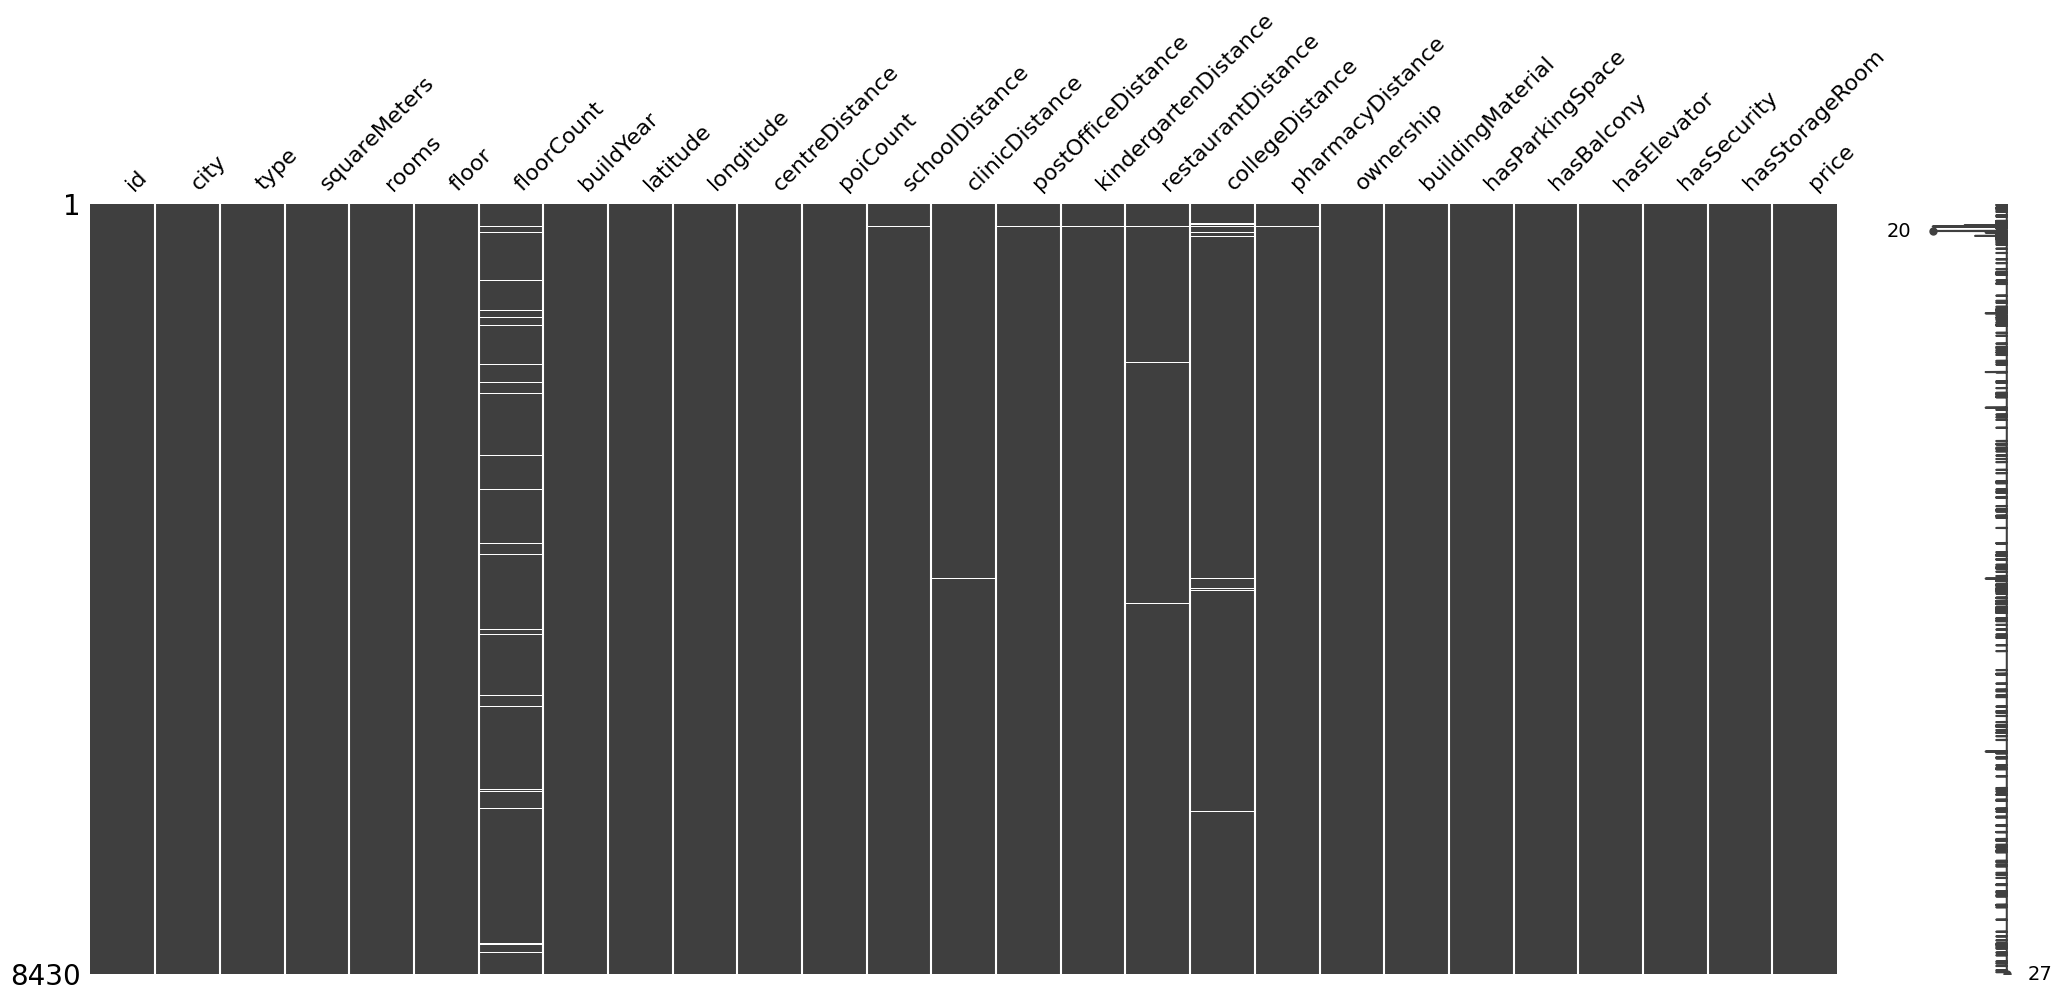

In [95]:
msno.matrix(df)
plt.show()

*Wizualizacja połączenia braków danych*

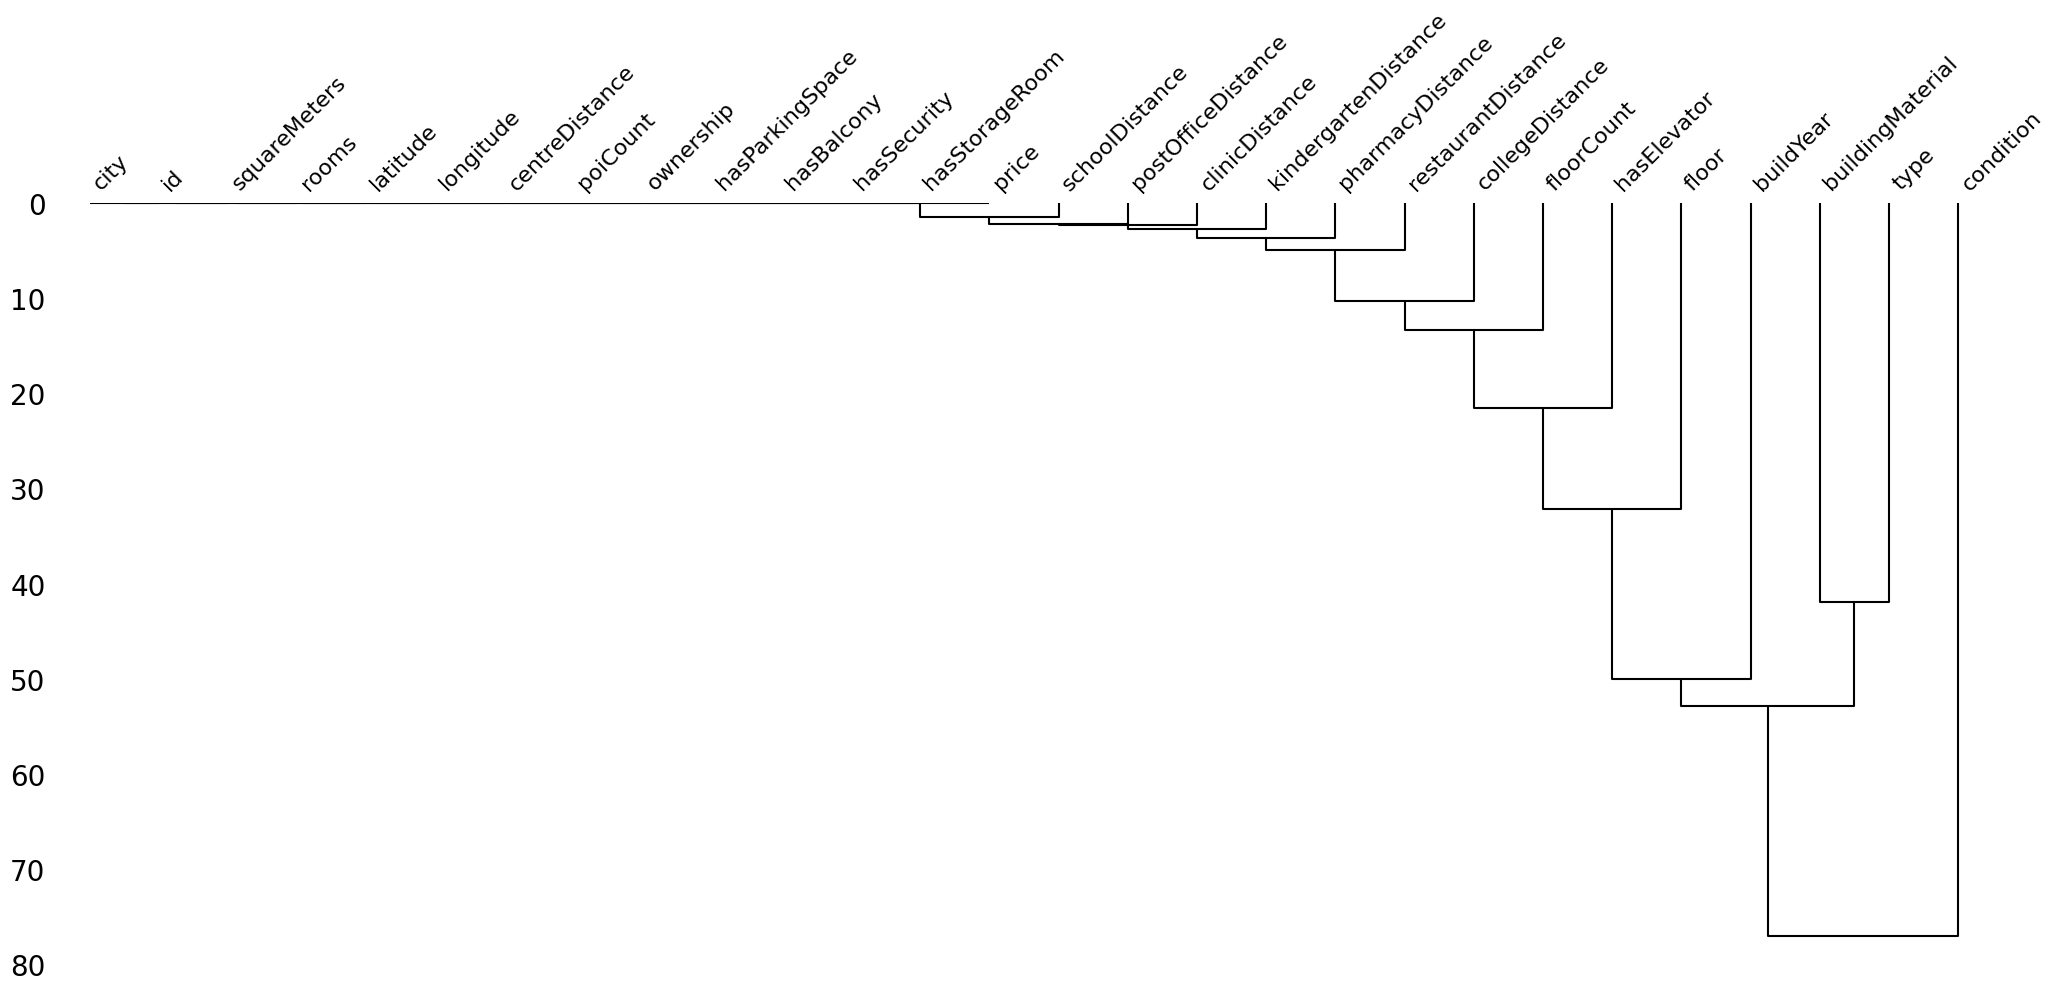

In [ ]:
msno.dendrogram(df)
plt.show()

*Wizualizacja braków procentowych*

<Axes: >

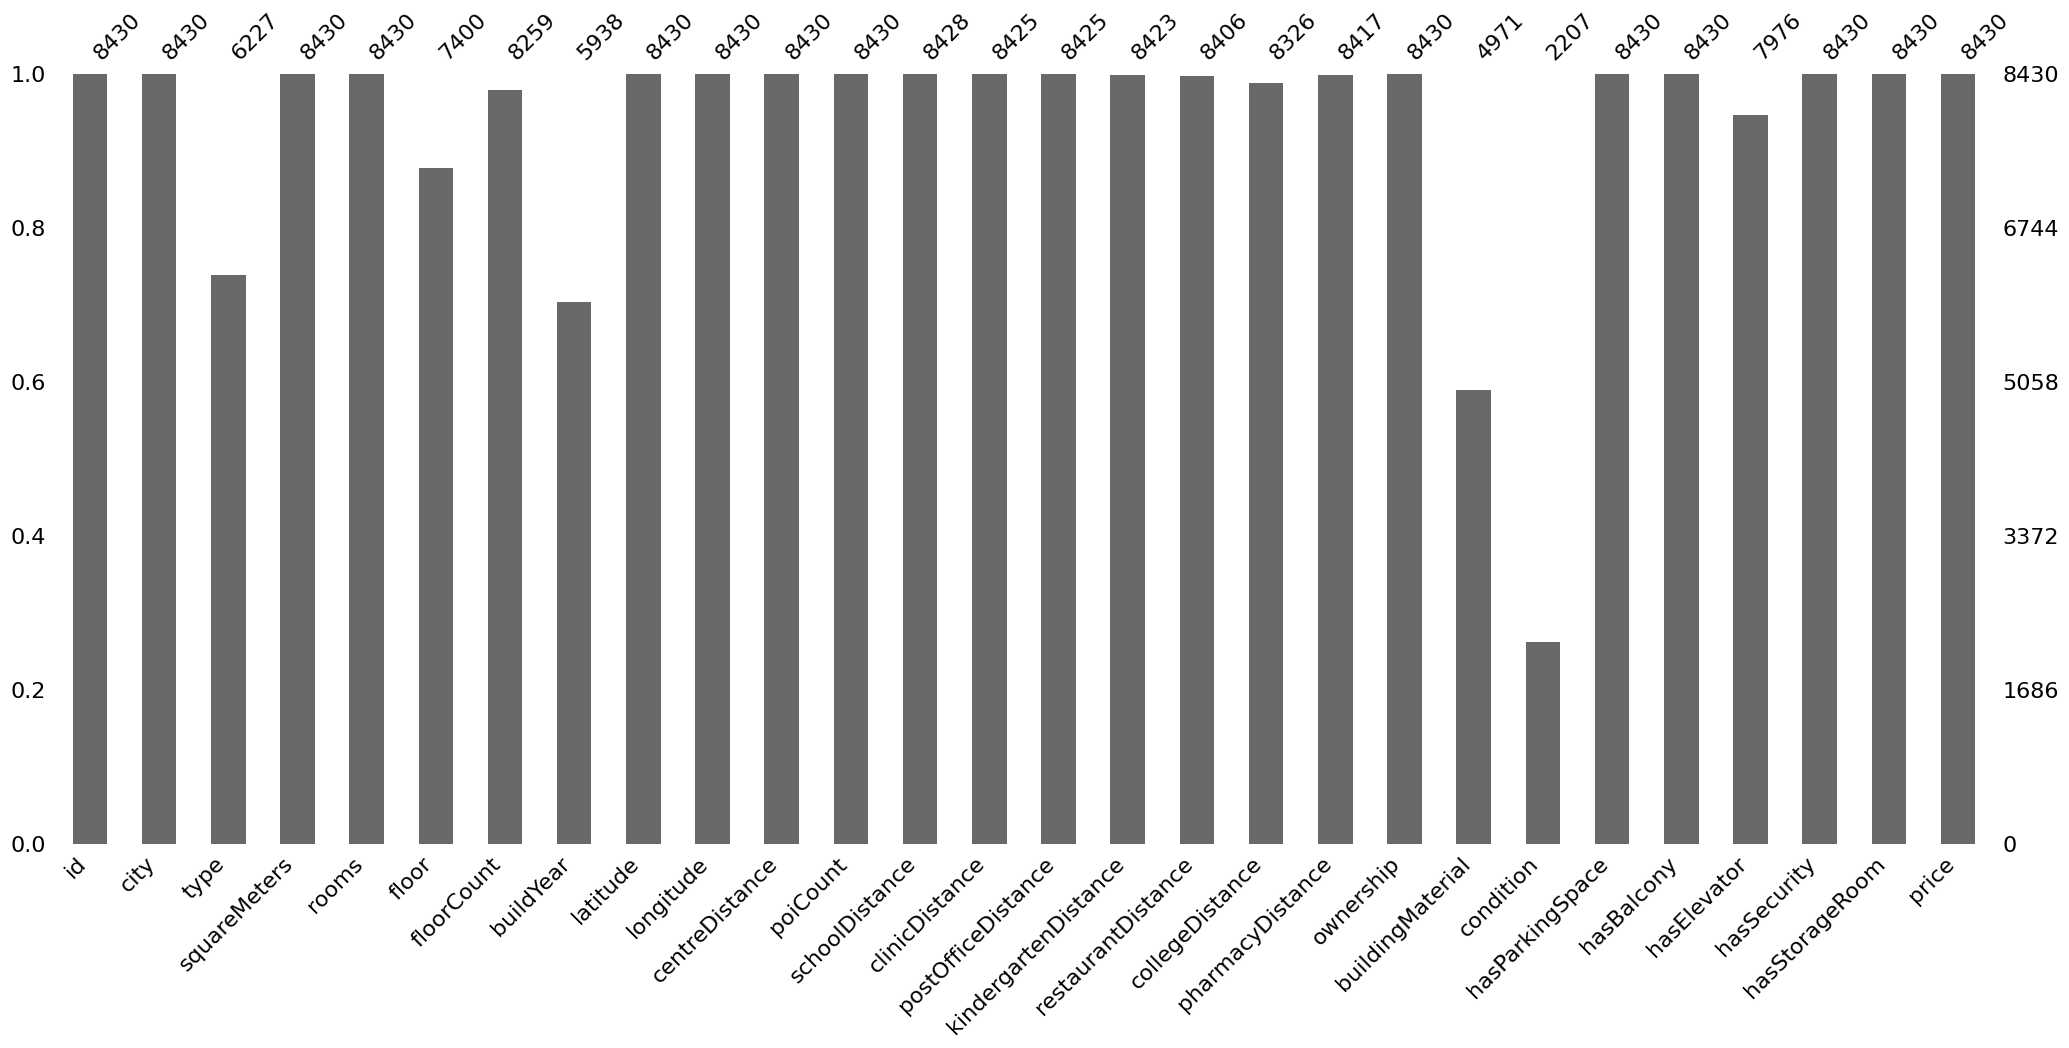

In [ ]:
msno.bar(df)

*Uzupełnianie braków danych*

In [5]:
df['type'] = df['type'].fillna('unknown')
df['buildYear'] = df['buildYear'].fillna(0)
df['floor'] = df['floor'].fillna(-1)
df['buildingMaterial'] = df['buildingMaterial'].fillna('unknown')
df['hasElevator'] = df['hasElevator'].fillna('unknown')

#ze względu na dużą liczbę braków, usuwamy kolumnę conditio z analizy 
df = df.drop(columns=['condition'])
print(df.info())

NameError: name 'df' is not defined

*Usuwamy pojedyńcze wiersze ze względu na małą liczbę danych*

In [88]:
df_braki = ['collegeDistance', 'pharmacyDistance', 'restaurantDistance', 'schoolDistance', 'postOfficeDistance','kindergartenDistance', 'clinicDistance','floorCount']
df_cleaned = df.dropna(subset=df_braki)
df_cleaned.info()


<class 'pandas.DataFrame'>
Index: 8122 entries, 0 to 8429
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    8122 non-null   str    
 1   city                  8122 non-null   str    
 2   type                  8122 non-null   str    
 3   squareMeters          8122 non-null   float64
 4   rooms                 8122 non-null   float64
 5   floor                 8122 non-null   float64
 6   floorCount            8122 non-null   float64
 7   buildYear             8122 non-null   float64
 8   latitude              8122 non-null   float64
 9   longitude             8122 non-null   float64
 10  centreDistance        8122 non-null   float64
 11  poiCount              8122 non-null   float64
 12  schoolDistance        8122 non-null   float64
 13  clinicDistance        8122 non-null   float64
 14  postOfficeDistance    8122 non-null   float64
 15  kindergartenDistance  8122 non-null  

### Zamiana typu danych ###

*Zamiana typu danych na int64*

In [ ]:
df_cleaned[['rooms', 'floor', 'floorCount','buildYear','poiCount']] = df_cleaned[['rooms', 'floor', 'floorCount','buildYear','poiCount']].astype('int64')

*Zamiana typu danych na float64*

In [ ]:
df_cleaned[['price']] = df_cleaned[['price']].astype('float64')

*Zamiana typu danych na string*

In [ ]:
df_cleaned[['id']] = df_cleaned[['id']].astype('str')

*Zamiana typu danych na binarne*

In [92]:
binarne = ['hasParkingSpace', 'hasBalcony', 'hasSecurity', 'hasStorageRoom']
df_cleaned[binarne] = df_cleaned[binarne].replace({'yes': 1, 'no': 0}).astype('int64')

## Etap 2: wizualizacja danych ##

*Wizualizacja z seaborn - histogram ceny mieszkań z logarytmiczną skalą*

<Axes: xlabel='price', ylabel='Count'>

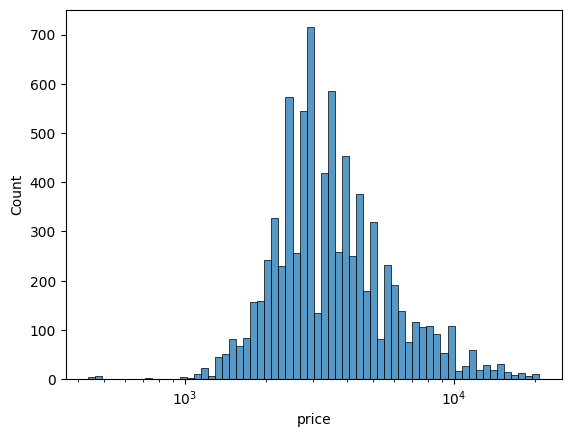

In [98]:
sns.histplot(data = df_cleaned, x = 'price', log_scale=True)

*Wizualizacja z seaborn - histogoram cen mieszkań w zależności od miasta*

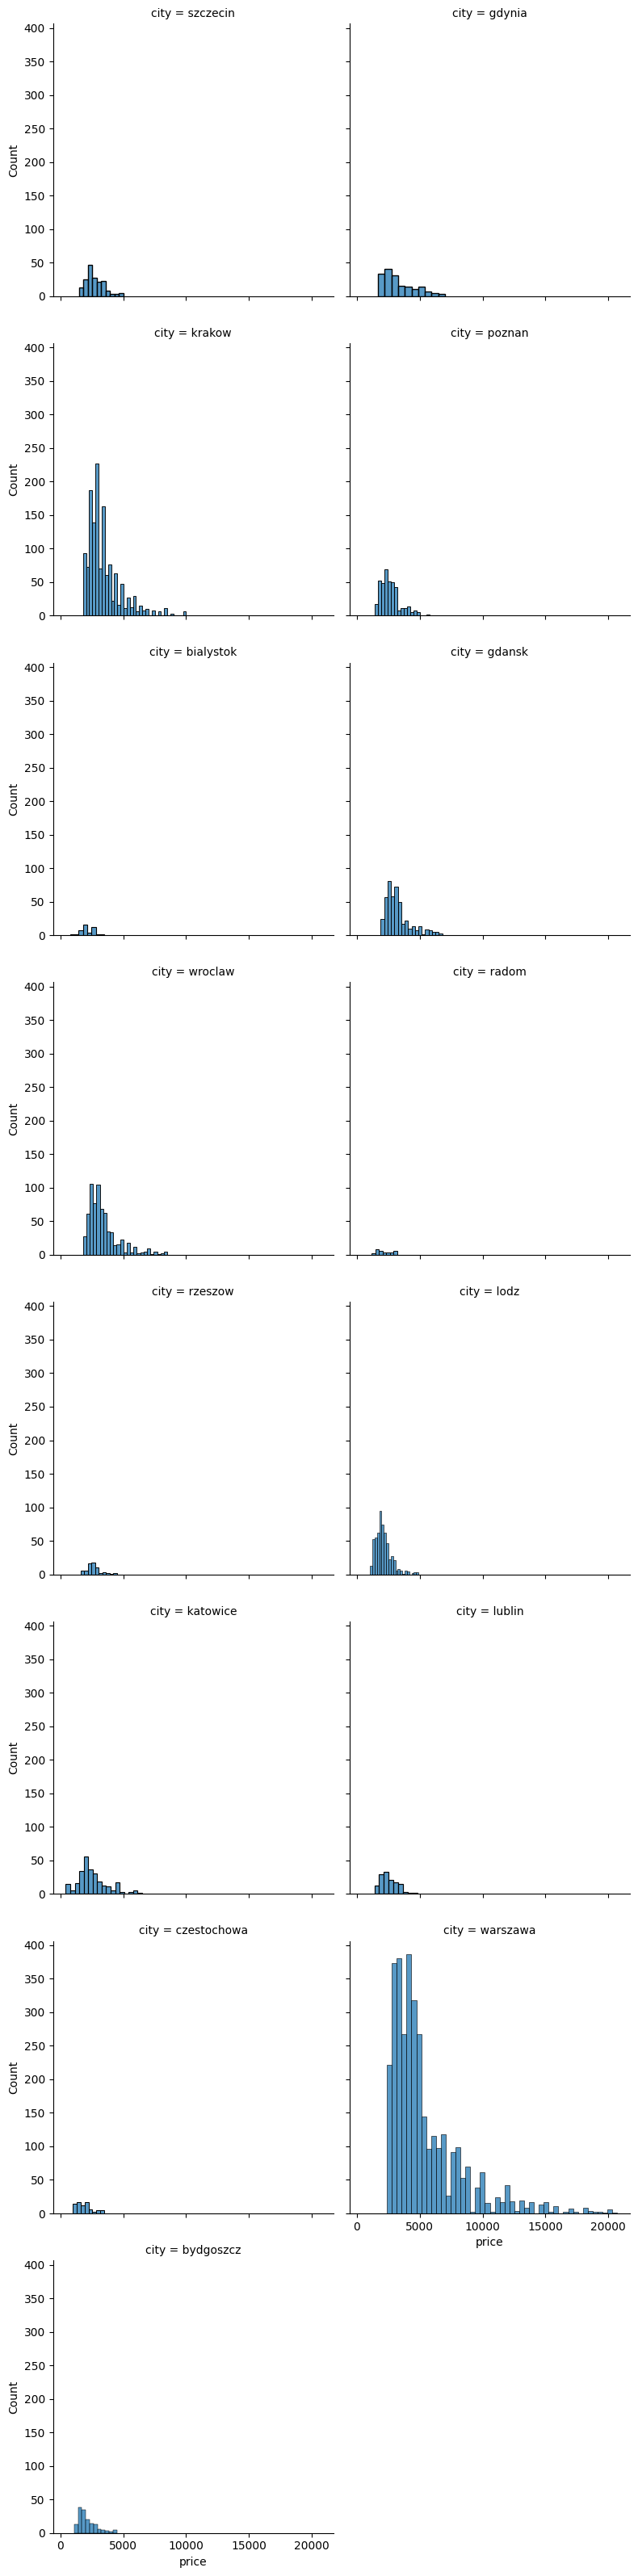

In [73]:
wykres = sns.FacetGrid(df_cleaned, col='city', col_wrap=2, height=4)
wykres.map(sns.histplot, 'price')

*Wizualizacja z seaborn - wykres punktowy cena vs m<sup>2</sup>*

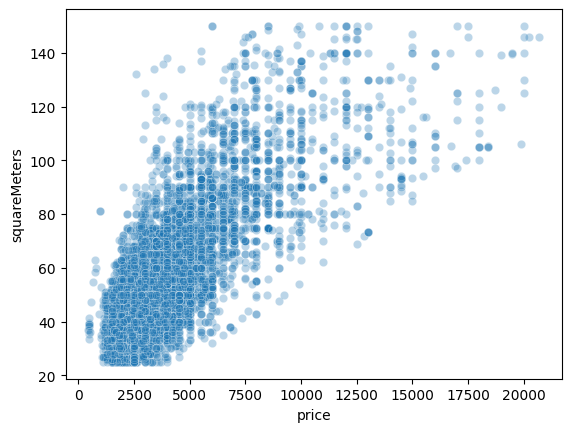

In [74]:
sns.scatterplot(data = df_cleaned, x = 'price', y = 'squareMeters', alpha = .3);

*Wizualizacja z plotly - wykres interaktywny cena vs m<sup>2</sup>*

In [75]:
fig = px.scatter(
    df_cleaned, 
    x="price", 
    y="squareMeters", 
    color="city",       
    opacity=0.5,        
    title="Interaktywny rozkład: Cena vs Metraż"
)

fig.show()

*Wizualizacja z seaborn - wykres liniowy cena nieruchomości vs rok budowy*

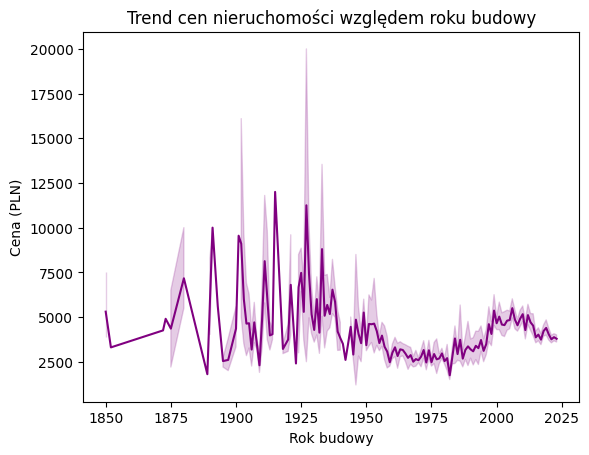

In [76]:
sns.lineplot(
    data=df_cleaned[df_cleaned['buildYear'] > 0], 
    x='buildYear', 
    y='price',
    color='purple'
)

plt.title('Trend cen nieruchomości względem roku budowy')
plt.xlabel('Rok budowy')
plt.ylabel('Cena (PLN)')
plt.show()

By zapewnić czytelność wizualizacji, z zestawu danych usunięto wartości roku budowy równe 0, ponieważ zostało to określone jako brak informacji.

*Wizualizacja z seaborn - wykres słupkowy kolorowy typ nieruchomości w danych mieście vs cena mieszkań*

<Axes: xlabel='city', ylabel='price'>

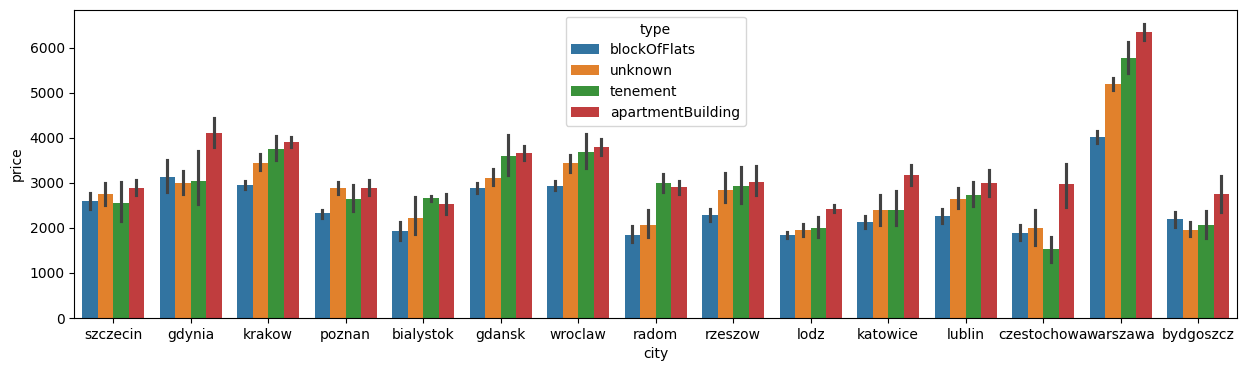

In [77]:
plt.figure(figsize=(15,4))
sns.barplot(data = df_cleaned,
           x = "city", y = "price", hue = "type")

*Wizualizacja z seaborn - wykres pudełkowy dystans od centrum vs miasto*

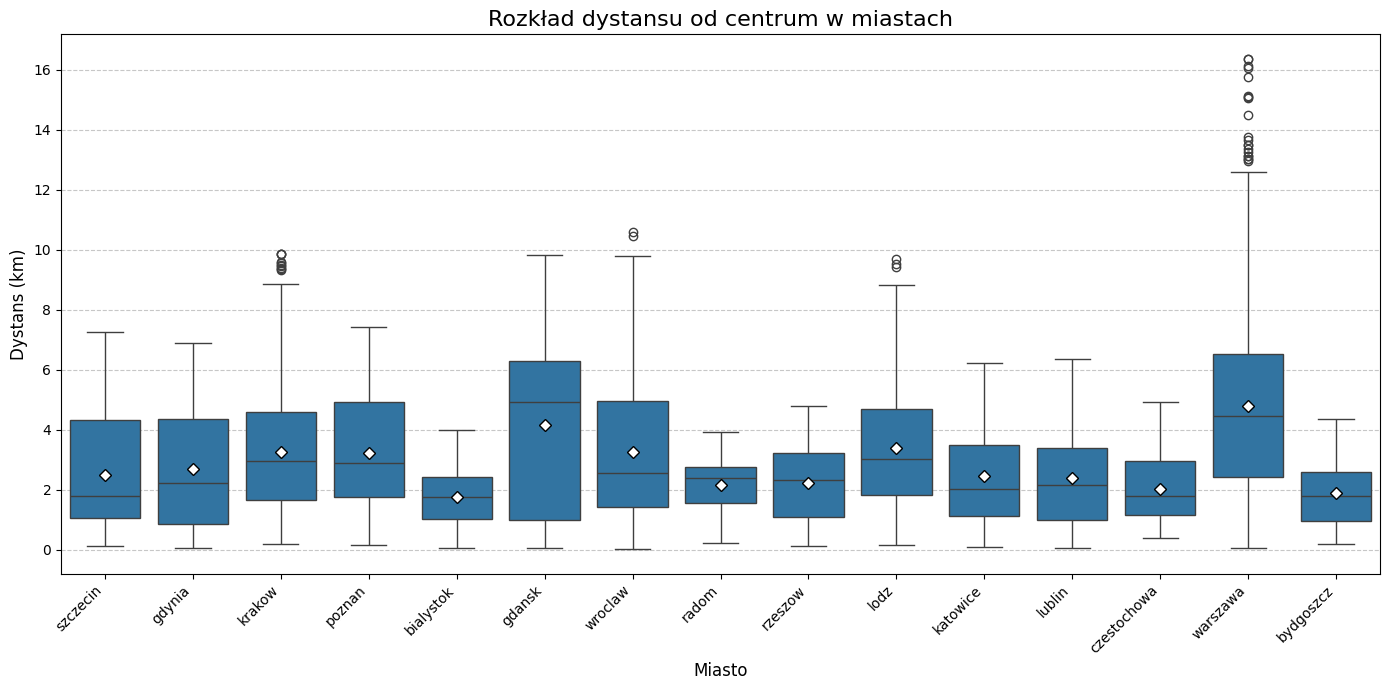

In [78]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_cleaned, x='city', y='centreDistance', showmeans=True, 
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black"})
plt.title('Rozkład dystansu od centrum w miastach', fontsize=16)
plt.xlabel('Miasto', fontsize=12)
plt.ylabel('Dystans (km)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Etap 3: analiza opisowa ##